In [1]:
import copy # copiar variables
import os   # gestionar rutas
import uproot   # Leer archivos ROOT sin usar ROOT directamente.
import awkward as ak  # Manejar arreglos tipo "jagged" (listas de listas, una por evento).
import vector   # vectores de Lorentz
vector.register_awkward()
import matplotlib.pyplot as plt # Para hacer gráficos.
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import tqdm # barras de progreso
import atlasopenmagic as atom # Paquete de datos abiertos ATLAS
from tabulate import tabulate # Para hacer tablas
import csv
from matplotlib.ticker import FixedLocator, FixedFormatter

## Estoy usando los datos de: 

## https://opendata.cern.ch/record/80036

In [2]:
base = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos"

archivos = [
    f"{base}/DAOD_HION14.41691891._000110.pool.root.1",
    f"{base}/DAOD_HION14.41691891._000119.pool.root.1",
]

Usar el archivo número

In [3]:
print('Objetos TTree dentro del archivo ROOT:')
for ii in uproot.open(archivos[0]).keys():
    print('-',ii)

Objetos TTree dentro del archivo ROOT:
- ##Params;2
- ##Params;1
- ##Shapes;2
- ##Shapes;1
- ##Links;2
- ##Links;1
- CollectionTree;1
- POOLContainer;1
- POOLContainerForm;1
- POOLCollectionTree;1
- MetaData;1
- MetaDataHdr;1
- MetaDataHdrForm;1


# Creando dos diccionarios, uno que tenga información de las partículas y otro que tenga información de los eventos (colisiones)

In [4]:
# --- forzar el TTree correcto en cada archivo ---
archivos_ct = [{a: "CollectionTree"} for a in archivos]

# --- ramas ---
ramas = [
    "InDetTrackParticlesAuxDyn.qOverP",
    "InDetTrackParticlesAuxDyn.theta",
    "InDetTrackParticlesAuxDyn.phi",
    "EventInfoAuxDyn.FCalEtA",
    "EventInfoAuxDyn.FCalEtA_Q2x",
    "EventInfoAuxDyn.FCalEtA_Q2y",
    "EventInfoAuxDyn.CentralityMin",
    "EventInfoAuxDyn.CentralityMax",
]

# --- contadores por archivo (USANDO SOLO EL NOMBRE) ---
nombres = [os.path.basename(a) for a in archivos]
eventos_por_archivo = {name: 0 for name in nombres}
Nevt_total = 0

for arrays_data, report in uproot.iterate(
    archivos_ct,
    ramas,
    step_size="200 MB",
    library="ak",
    timeout=600,
    report=True,
):
    archivo_actual = os.path.basename(report.file_path)  # << clave robusta

    # (NO necesitas zippear particulas/eventos para contar eventos; pero lo dejo como lo tenías)
    particulas = ak.zip(
        {
            "qOverP": arrays_data["InDetTrackParticlesAuxDyn.qOverP"],
            "theta": arrays_data["InDetTrackParticlesAuxDyn.theta"],
            "phi":   arrays_data["InDetTrackParticlesAuxDyn.phi"],
        }
    )

    eventos = ak.zip(
        {
            "FCalEtA":        arrays_data["EventInfoAuxDyn.FCalEtA"],
            "FCalEtA_Q2x":    arrays_data["EventInfoAuxDyn.FCalEtA_Q2x"],
            "FCalEtA_Q2y":    arrays_data["EventInfoAuxDyn.FCalEtA_Q2y"],
            "CentralityMin":  arrays_data["EventInfoAuxDyn.CentralityMin"],
            "CentralityMax":  arrays_data["EventInfoAuxDyn.CentralityMax"],
        }
    )

    n_evt_chunk = len(eventos)

    # por si report trae un nombre que no está en tu lista (raro, pero posible)
    if archivo_actual not in eventos_por_archivo:
        eventos_por_archivo[archivo_actual] = 0

    eventos_por_archivo[archivo_actual] += n_evt_chunk
    Nevt_total += n_evt_chunk

print("\nResumen de eventos por archivo:")
for name, n in eventos_por_archivo.items():
    print(f"{name} : {n} eventos")

print("\nEventos totales:", Nevt_total)


Resumen de eventos por archivo:
DAOD_HION14.41691891._000110.pool.root.1 : 200538 eventos
DAOD_HION14.41691891._000119.pool.root.1 : 201562 eventos

Eventos totales: 402100


## Un ejemplo de cómo llamar las ramas que tengo en el diccionario "partículas" y "eventos" en el último chunk.

In [5]:
particulas.theta, particulas.phi, eventos.CentralityMin

(<Array [[2.93, 2.93, 2.77, ..., 2.99, 1.67], ...] type='17161 * var * float32'>,
 <Array [[-1.92, -2.62, ..., -2.33, -0.489], ...] type='17161 * var * float32'>,
 <Array [56, 36, 77, 3, 63, 42, ..., 80, 48, 36, 72, 80] type='17161 * float32'>)

# Numero de eventos del chunk actual (200 MB a la vez):

In [6]:
print("Número de eventos en 'particulas':", len(particulas))
print("Número de eventos en 'eventos':", len(eventos))

Número de eventos en 'particulas': 17161
Número de eventos en 'eventos': 17161


# Numero total de eventos (Colisiones de iones de plomo - plomo)

In [7]:
Nevt_total = 0
Ntracks_total = 0
Nevt_particulas_total = 0

for arrays in uproot.iterate(
    archivos_ct,
    ramas,
    step_size="200 MB",
    library="ak",
    timeout=600,
):
    particulas = ak.zip(
        {
            "qOverP": arrays["InDetTrackParticlesAuxDyn.qOverP"],
            "theta": arrays["InDetTrackParticlesAuxDyn.theta"],
            "phi":   arrays["InDetTrackParticlesAuxDyn.phi"],
        }
    )

    eventos = ak.zip(
        {
            "FCalEtA":        arrays["EventInfoAuxDyn.FCalEtA"],
            "FCalEtA_Q2x":    arrays["EventInfoAuxDyn.FCalEtA_Q2x"],
            "FCalEtA_Q2y":    arrays["EventInfoAuxDyn.FCalEtA_Q2y"],
            "CentralityMin":  arrays["EventInfoAuxDyn.CentralityMin"],
            "CentralityMax":  arrays["EventInfoAuxDyn.CentralityMax"],
        }
    )

    # --- lo que estás analizando en ESTE chunk ---
    Nevt_chunk = len(eventos)                      # eventos (EventInfo)
    Nevt_particulas_chunk = len(particulas)        # eventos (tracks agrupados por evento)
    Ntracks_chunk = int(ak.sum(ak.num(particulas.qOverP)))  # tracks

    # --- acumular para TODOS los archivos ---
    Nevt_total += Nevt_chunk
    Nevt_particulas_total += Nevt_particulas_chunk
    Ntracks_total += Ntracks_chunk

print("Eventos analizados (eventos):", Nevt_total)
print("Eventos analizados (particulas):", Nevt_particulas_total)
print("Tracks/partículas analizadas (sumando los 3 archivos):", Ntracks_total)

Eventos analizados (eventos): 402100
Eventos analizados (particulas): 402100
Tracks/partículas analizadas (sumando los 3 archivos): 358503063


Se puede observar que en eventos y partículas hay la misma cantidad de eventos (tiene sentido).

# Centralidad promedio por evento

In [8]:
centrality_prom_event = []   # aquí se acumula TODA la centralidad

for arrays in uproot.iterate(
    archivos_ct,
    [
        "EventInfoAuxDyn.CentralityMin",
        "EventInfoAuxDyn.CentralityMax",
    ],
    step_size="200 MB",
    library="ak",
    timeout=600,
):
    eventos = ak.zip(
        {
            "CentralityMin": arrays["EventInfoAuxDyn.CentralityMin"],
            "CentralityMax": arrays["EventInfoAuxDyn.CentralityMax"],
        }
    )

    centrality_prom_event_chunk = 0.5 * (
        eventos.CentralityMin + eventos.CentralityMax
    )

    centrality_prom_event.append(centrality_prom_event_chunk)

# unir todos los chunks
centrality_prom_event = ak.concatenate(centrality_prom_event)

# ---- PRINTS IMPORTANTES ----
print("Número total de eventos (centrality_prom_event):", len(centrality_prom_event))

Número total de eventos (centrality_prom_event): 402100


# Cantidad de eventos segun la centralidad de la colisión

In [9]:
# --- USAR centrality_prom_event YA CALCULADA ---
# (contiene UN valor de centralidad por evento, para TODOS los archivos)

print("Número total de eventos en centrality_prom_event:", len(centrality_prom_event))

cent = ak.to_numpy(centrality_prom_event)
cent = cent[np.isfinite(cent)]

# =========================================================
# Intervalos pedidos: 0–5, 5–10, 10–30, 30–50, 50–70, 70–100
# =========================================================
bins   = np.array([0, 5, 10, 30, 50, 70, 100], dtype=float)
labels = ["0-5%", "5-10%", "10-30%", "30-50%", "50-70%", "70-100%"]

# Contar eventos por clase
cent_classes = pd.cut(
    cent,
    bins=bins,
    labels=labels,
    right=False,          # [a,b)
    include_lowest=True
)
Nevt = cent_classes.value_counts().reindex(labels, fill_value=0)

# Tabla
total_evt = int(Nevt.sum())
tabla_evt = pd.DataFrame({
    "Clase de centralidad": Nevt.index,
    "N_evt": Nevt.values.astype(int),
})
tabla_evt["Porcentaje [%]"] = 100.0 * tabla_evt["N_evt"] / total_evt if total_evt > 0 else 0.0

# Fila final: total
tabla_evt.loc[len(tabla_evt)] = ["Total de eventos", total_evt, 100.0]

# Mostrar tabla bonita
display(
    tabla_evt.style.format({
        "N_evt": "{:d}",
        "Porcentaje [%]": "{:.3f}",
    })
)

# Diccionario útil (solo clases, sin la fila Total)
Nevt_dict = dict(zip(labels, Nevt.values.astype(int)))

Número total de eventos en centrality_prom_event: 402100


,Clase de centralidad,N_evt,Porcentaje [%]
0,0-5%,16712,4.156
1,5-10%,16894,4.201
2,10-30%,67844,16.872
3,30-50%,68234,16.969
4,50-70%,67963,16.902
5,70-100%,164453,40.899
6,Total de eventos,402100,100.000


## Cantidad de partículas en una determinada clase de centralidad

In [10]:
# --- acumuladores globales ---
N_part_total = 0

# 0–5, 5–10, y luego 10–20, 20–30, ..., 90–100 (sin 0–10)
labels = ["0-5%", "5-10%"] + [f"{i}-{i+10}%" for i in range(10, 100, 10)]
N_part_por_centralidad = {lab: 0 for lab in labels}

# --- recorrer TODOS los archivos y chunks ---
for arrays in uproot.iterate(
    archivos_ct,
    [
        "InDetTrackParticlesAuxDyn.qOverP",
        "InDetTrackParticlesAuxDyn.theta",
        "InDetTrackParticlesAuxDyn.phi",
        "EventInfoAuxDyn.CentralityMin",
        "EventInfoAuxDyn.CentralityMax",
    ],
    step_size="200 MB",
    library="ak",
    timeout=600,
):
    particulas = ak.zip(
        {
            "qOverP": arrays["InDetTrackParticlesAuxDyn.qOverP"],
            "theta": arrays["InDetTrackParticlesAuxDyn.theta"],
            "phi":   arrays["InDetTrackParticlesAuxDyn.phi"],
        }
    )

    centrality_prom_event = 0.5 * (
        arrays["EventInfoAuxDyn.CentralityMin"] + arrays["EventInfoAuxDyn.CentralityMax"]
    )

    # --- contar partículas totales en este chunk ---
    N_part_total += int(ak.sum(ak.num(particulas.qOverP)))

    # --- 0–5 ---
    mask_evt = (centrality_prom_event >= 0) & (centrality_prom_event < 5)
    N_part_por_centralidad["0-5%"] += int(ak.sum(ak.num(particulas[mask_evt].qOverP)))

    # --- 5–10 ---
    mask_evt = (centrality_prom_event >= 5) & (centrality_prom_event < 10)
    N_part_por_centralidad["5-10%"] += int(ak.sum(ak.num(particulas[mask_evt].qOverP)))

    # --- 10–20, ..., 90–100 ---
    for i in range(10, 100, 10):
        mask_evt = (centrality_prom_event >= i) & (centrality_prom_event < i + 10)
        N_part_por_centralidad[f"{i}-{i+10}%"] += int(ak.sum(ak.num(particulas[mask_evt].qOverP)))

# --- imprimir resultados ---
for lab in labels:
    print(f"Número de partículas en {lab} :", N_part_por_centralidad[lab])

print("Número total de partículas (0–100%):", N_part_total)

Número de partículas en 0-5% : 78726316
Número de partículas en 5-10% : 59607311
Número de partículas en 10-20% : 84323990
Número de partículas en 20-30% : 54670736
Número de partículas en 30-40% : 34974113
Número de partículas en 40-50% : 23522649
Número de partículas en 50-60% : 12030153
Número de partículas en 60-70% : 6235078
Número de partículas en 70-80% : 2813861
Número de partículas en 80-90% : 0
Número de partículas en 90-100% : 1598856
Número total de partículas (0–100%): 358503063


# Momento transverso

In [11]:
# --- acumuladores globales ---
pt_flattened_all = []   # aquí guardaremos TODOS los pT (todas las partículas)
N_evt_total = 0
N_part_total = 0

# --- recorrer TODOS los archivos y chunks ---
for arrays in uproot.iterate(
    archivos_ct,
    [
        "InDetTrackParticlesAuxDyn.qOverP",
        "InDetTrackParticlesAuxDyn.theta",
    ],
    step_size="200 MB",
    library="ak",
    timeout=600,
):
    # --- mismas variables que usabas antes (solo ramas necesarias) ---
    particulas = ak.zip(
        {
            "qOverP": arrays["InDetTrackParticlesAuxDyn.qOverP"],
            "theta":  arrays["InDetTrackParticlesAuxDyn.theta"],
        }
    )

    # --- contar eventos y partículas en este chunk ---
    N_evt_chunk = len(particulas)
    N_part_chunk = int(ak.sum(ak.num(particulas.qOverP)))
    N_evt_total += N_evt_chunk
    N_part_total += N_part_chunk

    # --- Filtrar datos válidos ---
    validas = (
        (particulas.qOverP != 0)
        & np.isfinite(particulas.qOverP)
        & np.isfinite(particulas.theta)
    )
    particulas = particulas[validas]

    # --- Calcular momento total y momento transverso ---
    p  = 1 / np.abs(particulas.qOverP)   # momento total
    pt = p * np.sin(particulas.theta)    # pT por evento

    # --- pasar a vector plano por partícula ---
    pt_flattened = ak.flatten(pt)

    # --- acumular ---
    pt_flattened_all.append(pt_flattened)

# --- concatenar todos los chunks ---
pt_flattened = ak.concatenate(pt_flattened_all)

# --- información pedida ---
print("Número total de eventos analizados:", N_evt_total)
print("Número total de partículas analizadas:", N_part_total)
print("Longitud de pt_flattened (partículas totales):", len(pt_flattened))

Número total de eventos analizados: 402100
Número total de partículas analizadas: 358503063
Longitud de pt_flattened (partículas totales): 358503063


# Seudorapidez

In [12]:
# --- acumulador global ---
eta_flat_all = []

# --- recorrer TODOS los archivos y chunks (solo la rama necesaria) ---
for arrays in uproot.iterate(
    archivos_ct,
    ["InDetTrackParticlesAuxDyn.theta"],
    step_size="200 MB",
    library="ak",
    timeout=600,
):
    # --- mismas variables que usabas antes ---
    particulas = ak.zip(
        {
            "theta": arrays["InDetTrackParticlesAuxDyn.theta"],
        }
    )

    # --- filtrar valores válidos ---
    validas = np.isfinite(particulas.theta)
    particulas = particulas[validas]

    # --- calcular pseudorrapidez η ---
    eta = -np.log(np.tan(particulas.theta / 2.0))   # por evento

    # --- aplanar por partícula ---
    eta_flat = ak.flatten(eta)

    # --- acumular ---
    eta_flat_all.append(eta_flat)

# --- concatenar todos los chunks ---
eta_flat = ak.concatenate(eta_flat_all)

# --- longitud pedida ---
print("Número total de partículas (η):", len(eta_flat))

Número total de partículas (η): 358503063


# Histograma de Seudorapidez

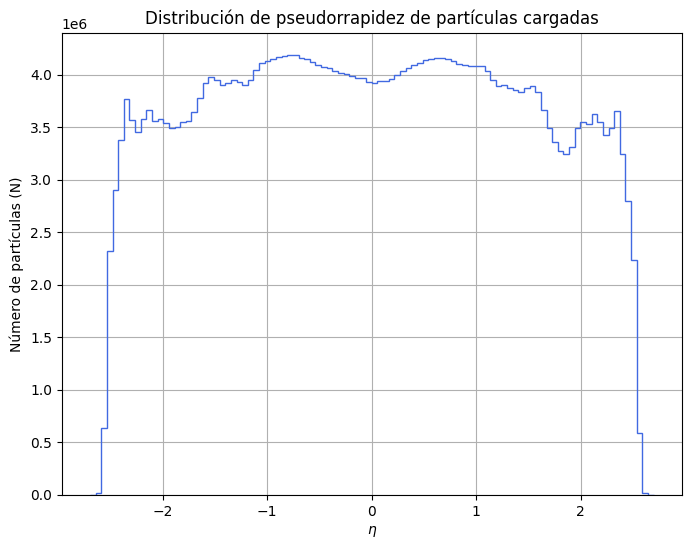

Número total de partículas usadas en el histograma: 358503063


In [13]:
# --- Histograma N vs η usando eta_flat ya calculada ---
plt.figure(figsize=(8,6))
plt.hist(
    eta_flat,
    bins=100,
    histtype="step",
    color="royalblue"
)

plt.xlabel(r"$\eta$")
plt.ylabel("Número de partículas (N)")
plt.title("Distribución de pseudorrapidez de partículas cargadas")
plt.grid(True)
plt.show()

# --- información útil ---
print("Número total de partículas usadas en el histograma:", len(eta_flat))

# Espectro de partículas por evento
## Promedio de partículas cargadas por evento por unidad de seudorapidez y momento transverso

# $$
\frac{1}{N_{evt}}\frac{d^{2}N_{PbPb}}{d\eta\, dp_{T}}
= \frac{1}{N_{evt}}\,E\,\frac{d^{3}N_{PbPb}}{d^{3}p}
$$

# Obs: Ya hice la demostración de la ecuación anterior.

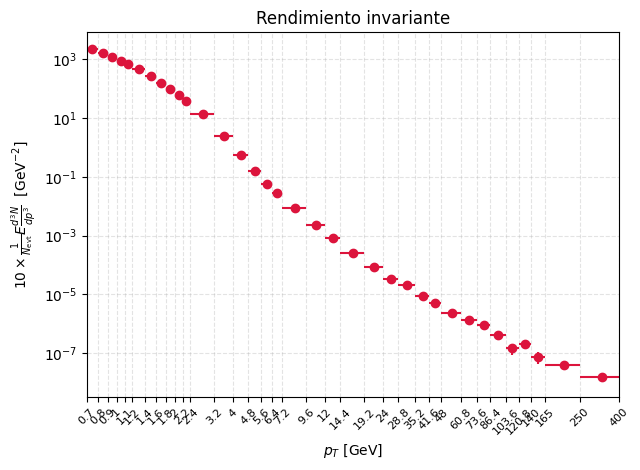


Eventos totales usados (sumando los 2 archivos) en 0-5%: 16712
Tabla: Rendimiento invariante


,pT_low [GeV],pT_high [GeV],pT_center [GeV],10*(1/Nevt)*E*d^3N/dp^3 [GeV^-2],stat_err [GeV^-2],counts
0,0.7,0.8,0.75,2239.8334549799,1.1924991726,3527892
1,0.8,0.9,0.85,1596.6438859512,0.9457479809,2850134
2,0.9,1.0,0.95,1173.8869983303,0.7670650549,2342007
3,1.0,1.1,1.05,898.2282838772,0.6382334590,1980680
4,1.1,1.2,1.15,675.0036006492,0.5286703804,1630205
5,1.2,1.4,1.3,454.1244582763,0.2883909495,2479628
6,1.4,1.6,1.5,266.9513390310,0.2058430835,1681867
7,1.6,1.8,1.7,160.9491223150,0.1501362978,1149227
8,1.8,2.0,1.9,98.8618410520,0.1113021114,788952
9,2.0,2.2,2.1,61.6899319776,0.0836302423,544129


In [14]:
# =========================
# 0) Definir clase de centralidad y factor del rendimiento invariante
# =========================
CENT_LO, CENT_HI = 0, 5
FACTOR_INV = 10

# =========================
# 1) Acumuladores para TODOS los archivos (todas las partículas)
# =========================
pt_intervalos = np.array([
    0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 3.2, 4.0,
    4.8, 5.6, 6.4, 7.2, 9.6, 12.0, 14.4, 19.2, 24.0, 28.8, 35.2, 41.6,
    48.0, 60.8, 73.6, 86.4, 103.6, 120.8, 140.0, 165.0, 250.0, 400.0
], dtype=float)

pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt      = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)

N_ij_total = np.zeros(len(Delta_pt), dtype=np.int64)
Nevt_total = 0

# =========================
# 2) Recorrer LOS DOS ARCHIVOS en chunks, y acumular TODO
# =========================
for arrays in uproot.iterate(
    archivos_ct,
    [
        "InDetTrackParticlesAuxDyn.qOverP",
        "InDetTrackParticlesAuxDyn.theta",
        "EventInfoAuxDyn.CentralityMin",
        "EventInfoAuxDyn.CentralityMax",
    ],
    step_size="200 MB",
    library="ak",
    timeout=600,
):
    centrality_prom_event = 0.5 * (
        arrays["EventInfoAuxDyn.CentralityMin"] + arrays["EventInfoAuxDyn.CentralityMax"]
    )

    mask_evt = (centrality_prom_event >= CENT_LO) & (centrality_prom_event < CENT_HI)

    Nevt_chunk = int(ak.sum(mask_evt))
    Nevt_total += Nevt_chunk
    if Nevt_chunk == 0:
        continue

    qOverP_sel = arrays["InDetTrackParticlesAuxDyn.qOverP"][mask_evt]
    theta_sel  = arrays["InDetTrackParticlesAuxDyn.theta"][mask_evt]

    validas = (qOverP_sel != 0) & np.isfinite(qOverP_sel) & np.isfinite(theta_sel)
    qOverP_sel = qOverP_sel[validas]
    theta_sel  = theta_sel[validas]

    p_mev  = 1.0 / np.abs(qOverP_sel)
    pt_gev = (p_mev * np.sin(theta_sel)) / 1000.0
    eta_sel = -np.log(np.tan(theta_sel / 2.0))

    mask_eta = np.abs(eta_sel) < 1.0
    pt_Filtrado = ak.to_numpy(ak.flatten(pt_gev[mask_eta]))

    N_ij_chunk, _ = np.histogram(pt_Filtrado, bins=pt_intervalos)
    N_ij_total += N_ij_chunk

# =========================
# 3) Normalización con TODOS los eventos (sumando los 2 archivos)
# =========================
Delta_eta  = 2.0
Espectro   = N_ij_total / (Nevt_total * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij_total) / (Nevt_total * Delta_eta * Delta_pt)

InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr   = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# =========================
# 4) Gráfica SOLO de rendimiento invariante
# =========================
mask_bins = N_ij_total > 0
x    = pt_centro_Bin[mask_bins]
y2   = InvYield[mask_bins]
e2   = InvErr[mask_bins]
xerr = np.vstack([x - pt_low[mask_bins], pt_high[mask_bins] - x])

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.8))
ax.errorbar(x, y2, xerr=xerr, yerr=e2, fmt="o", linestyle="none", capsize=0, color="crimson")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(pt_intervalos[0], pt_intervalos[-1])
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]")
ax.set_title(r"Rendimiento invariante")
ax.grid(True, which="both", ls="--", alpha=0.35)

ticks = pt_intervalos
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# =========================
# 5) Tabla SOLO de rendimiento invariante
#    - PTlow, PThigh: 1 decimal
#    - PT: 2 decimales
#    - última fila: total de partículas (suma de counts)
# =========================
col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"

tabla_invar = pd.DataFrame({
    "pT_low [GeV]":     pt_low[mask_bins],
    "pT_high [GeV]":    pt_high[mask_bins],
    "pT_center [GeV]":  pt_centro_Bin[mask_bins],
    col_y:              InvYield[mask_bins],
    "stat_err [GeV^-2]":InvErr[mask_bins],
    "counts":           N_ij_total[mask_bins],
})

# (opcional) redondeo numérico real en las columnas de pT (no solo formato)
tabla_invar["pT_low [GeV]"]    = tabla_invar["pT_low [GeV]"].map(lambda v: float(f"{v:.1f}"))
tabla_invar["pT_high [GeV]"]   = tabla_invar["pT_high [GeV]"].map(lambda v: float(f"{v:.1f}"))
tabla_invar["pT_center [GeV]"] = tabla_invar["pT_center [GeV]"].map(lambda v: float(f"{v:.2f}"))

# mantener rendimiento invariante con 10 decimales (como venías haciendo)
tabla_invar[col_y] = tabla_invar[col_y].map(lambda v: float(f"{v:.10f}"))
tabla_invar["stat_err [GeV^-2]"] = tabla_invar["stat_err [GeV^-2]"].map(lambda v: float(f"{v:.10f}"))

# fila final: total de partículas
total_part = int(tabla_invar["counts"].sum())
fila_total = {
    "pT_low [GeV]": np.nan,
    "pT_high [GeV]": np.nan,
    "pT_center [GeV]": "Total",
    col_y: np.nan,
    "stat_err [GeV^-2]": np.nan,
    "counts": total_part,
}
tabla_invar = pd.concat([tabla_invar, pd.DataFrame([fila_total])], ignore_index=True)

print(f"\nEventos totales usados (sumando los 2 archivos) en {CENT_LO}-{CENT_HI}%: {Nevt_total}")
print("Tabla: Rendimiento invariante")
display(tabla_invar.style.format({
    "pT_low [GeV]": "{:.1f}",
    "pT_high [GeV]": "{:.1f}",
    "pT_center [GeV]": "{}",
    col_y: "{:.10f}",
    "stat_err [GeV^-2]": "{:.10f}",
    "counts": "{:d}",
}))

### En el siguiente enlace, se muestra el resultado (gráfico) de lo que debería obtener:

### https://www.hepdata.net/record/ins1496050?version=2&table=Table%208

# Tabla comparativa de lo que yo calculé vs lo que obtuvo HEP


Tabla: Comparación ATLAS vs HEPData para centralidad 0-5%  (archivo: HEPData-ins1496050-v2-Table_1.csv)


,PTlow [GeV],PThigh [GeV],PT [GeV],Valor medido ATLAS,Valor medido HEP,Porcentaje de error [%],Cuentas ATLAS (tracks)
0,0.7,0.8,0.75,2239.833454979900125,2382.230000000000018,5.977447,3527892
1,0.8,0.9,0.85,1596.643885951199991,1798.220000000000027,11.209758,2850134
2,0.9,1.0,0.95,1173.886998330300003,1339.400000000000091,12.357250,2342007
3,1.0,1.1,1.05,898.228283877200056,1027.660000000000082,12.594799,1980680
4,1.1,1.2,1.15,675.003600649200052,763.706999999999994,11.614847,1630205
5,1.2,1.4,1.3,454.124458276300004,529.852999999999952,14.292368,2479628
6,1.4,1.6,1.5,266.951339030999975,309.115999999999985,13.640401,1681867
7,1.6,1.8,1.7,160.949122315000011,194.688999999999993,17.330141,1149227
8,1.8,2.0,1.9,98.861841052000003,117.241000000000000,15.676392,788952
9,2.0,2.2,2.1,61.689931977599997,75.129199999999997,17.888209,544129


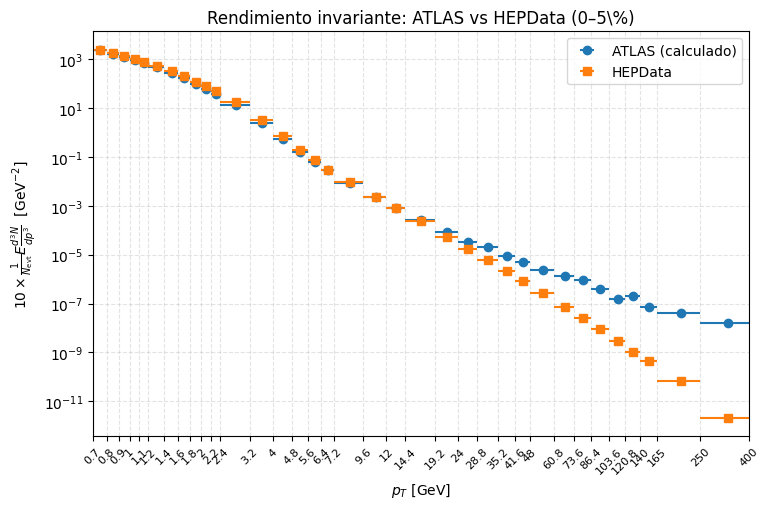

In [15]:
# =========================================================
# COMPARACIÓN ATLAS (calculado) vs HEPData  +  TABLA + GRÁFICO
#   - Asume que YA existen: tabla_invar, CENT_LO, CENT_HI, FACTOR_INV
# =========================================================
import re

# =========================================================
# 0) Mapeo centralidad -> archivo HEPData
# =========================================================
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_1.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_2.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_3.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_4.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_5.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_6.csv",
}

clave_cent = (CENT_LO, CENT_HI)
if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No tengo mapeado el archivo HEPData para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones válidas: {sorted(list(hep_archivos_por_centralidad.keys()))}"
    )

archivo_hep = hep_archivos_por_centralidad[clave_cent]

# =========================================================
# 1) Leer HEPData
# =========================================================
df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")

pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)

y_hep_raw = df_hep.iloc[:, 3].astype(float).to_numpy()

# Algunos HEPData vienen con factor tipo "1e-3 * value" en el nombre de columna:
factor_hep = 1.0
try:
    nombre_col_valor = str(df_hep.columns[3])
    mfac = re.match(r"^\s*([0-9]+(?:\.[0-9]+)?(?:e[+-]?\d+)?)\s*\*", nombre_col_valor, flags=re.IGNORECASE)
    if mfac:
        factor_hep = float(mfac.group(1))
except Exception:
    factor_hep = 1.0

# Reescalado a tu convención (si aplica a tu caso)
y_hep = y_hep_raw * (FACTOR_INV / factor_hep)

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_value": y_hep,
})

# =========================================================
# 2) Tabla ATLAS (desde tu cálculo en tabla_invar) + incluir counts
# =========================================================
col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"

cols_necesarias = ["pT_low [GeV]", "pT_high [GeV]", "pT_center [GeV]", col_y, "counts"]
faltan = [c for c in cols_necesarias if c not in tabla_invar.columns]
if faltan:
    raise ValueError(
        f"En tabla_invar faltan columnas necesarias: {faltan}\n"
        f"Columnas disponibles: {list(tabla_invar.columns)}"
    )

tabla_atlas = (
    tabla_invar[cols_necesarias]
    .copy()
    .rename(columns={
        col_y: "ATLAS_value",
        "counts": "Cuentas ATLAS (tracks)",
    })
)

# (Si tabla_invar tiene una última fila 'Total', la quitamos para comparar bin-a-bin)
tabla_atlas = tabla_atlas[pd.to_numeric(tabla_atlas["pT_low [GeV]"], errors="coerce").notna()].copy()

# =========================================================
# 3) MERGE robusto por bordes de bin
# =========================================================
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_value"]],
    on=["_low_key", "_high_key"],
    how="inner",
)

# =========================================================
# 4) Porcentaje de error
# =========================================================
tabla_comp["Porcentaje de error [%]"] = (
    np.abs(tabla_comp["ATLAS_value"] - tabla_comp["HEP_value"]) / tabla_comp["HEP_value"]
) * 100.0

# =========================================================
# 5) Limpieza + ORDEN de columnas (cuentas a la par del error)
# =========================================================
tabla_comp = (
    tabla_comp
    .drop(columns=["_low_key", "_high_key"])
    .rename(columns={
        "pT_low [GeV]": "PTlow [GeV]",
        "pT_high [GeV]": "PThigh [GeV]",
        "pT_center [GeV]": "PT [GeV]",
        "ATLAS_value": "Valor medido ATLAS",
        "HEP_value": "Valor medido HEP",
    })
)

# Reordenar: ... error y a la par cuentas
tabla_comp = tabla_comp[[
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "Valor medido ATLAS",
    "Valor medido HEP",
    "Porcentaje de error [%]",
    "Cuentas ATLAS (tracks)",
]]

# =========================================================
# 6) Agregar fila final: TOTAL de cuentas (partículas)
# =========================================================
total_cuentas = int(pd.to_numeric(tabla_comp["Cuentas ATLAS (tracks)"], errors="coerce").fillna(0).sum())

fila_total = {
    "PTlow [GeV]": np.nan,
    "PThigh [GeV]": np.nan,
    "PT [GeV]": "Total",
    "Valor medido ATLAS": np.nan,
    "Valor medido HEP": np.nan,
    "Porcentaje de error [%]": np.nan,
    "Cuentas ATLAS (tracks)": total_cuentas,
}
tabla_comp = pd.concat([tabla_comp, pd.DataFrame([fila_total])], ignore_index=True)

# =========================================================
# 7) Mostrar tabla final
# =========================================================
print(f"\nTabla: Comparación ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}%  (archivo: {archivo_hep})")
display(
    tabla_comp.style.format({
        "PTlow [GeV]": "{:.1f}",
        "PThigh [GeV]": "{:.1f}",
        "PT [GeV]": "{}",
        "Valor medido ATLAS": "{:.15f}",
        "Valor medido HEP": "{:.15f}",
        "Porcentaje de error [%]": "{:.6f}",
        "Cuentas ATLAS (tracks)": "{:d}",
    })
)

# =========================================================
# 8) GRÁFICO SUPERPUESTO: ATLAS vs HEPData (log-log)
#     (No grafico la fila "Total")
# =========================================================
tabla_plot = tabla_comp[tabla_comp["PT [GeV]"].apply(lambda x: isinstance(x, (int, float, np.floating)))].copy()

x      = tabla_plot["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_plot["Valor medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_plot["Valor medido HEP"].to_numpy(dtype=float)

ptlow  = tabla_plot["PTlow [GeV]"].to_numpy(dtype=float)
pthigh = tabla_plot["PThigh [GeV]"].to_numpy(dtype=float)
xerr   = np.vstack([x - ptlow, pthigh - x])

m = np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) & (x > 0) & (y_at > 0) & (y_hep2 > 0)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(x[m], y_at[m], xerr=xerr[:, m], fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)")
ax.errorbar(x[m], y_hep2[m], xerr=xerr[:, m], fmt="s", linestyle="none", capsize=0, label="HEPData")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]")
ax.set_title(rf"Rendimiento invariante: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%)")
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

# ticks = bordes exactos (si existe pt_intervalos lo usa; si no, usa bordes de la tabla)
if "pt_intervalos" in globals():
    ticks = np.array(pt_intervalos, dtype=float)
else:
    ticks = np.unique(np.concatenate([ptlow, pthigh]))

ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()
ax.set_xlim(float(np.min(ticks)), float(np.max(ticks)))

plt.tight_layout()
plt.show()

### Observación: Obtuve una mejor aproximación de los valores numéricos al usar 2 archivos.

# Recortando el intervalo


Tabla: Comparación ATLAS vs HEPData para centralidad 0-5% (archivo: HEPData-ins1496050-v2-Table_1.csv)  con recorte pT <= 19.2 GeV


,PTlow [GeV],PThigh [GeV],PT [GeV],Valor medido ATLAS,Valor medido HEP,Porcentaje de error [%],Cuentas ATLAS (tracks)
0,0.7,0.8,0.75,2239.833454979900125,2382.230000000000018,5.977447,3527892
1,0.8,0.9,0.85,1596.643885951199991,1798.220000000000027,11.209758,2850134
2,0.9,1.0,0.95,1173.886998330300003,1339.400000000000091,12.357250,2342007
3,1.0,1.1,1.05,898.228283877200056,1027.660000000000082,12.594799,1980680
4,1.1,1.2,1.15,675.003600649200052,763.706999999999994,11.614847,1630205
5,1.2,1.4,1.3,454.124458276300004,529.852999999999952,14.292368,2479628
6,1.4,1.6,1.5,266.951339030999975,309.115999999999985,13.640401,1681867
7,1.6,1.8,1.7,160.949122315000011,194.688999999999993,17.330141,1149227
8,1.8,2.0,1.9,98.861841052000003,117.241000000000000,15.676392,788952
9,2.0,2.2,2.1,61.689931977599997,75.129199999999997,17.888209,544129


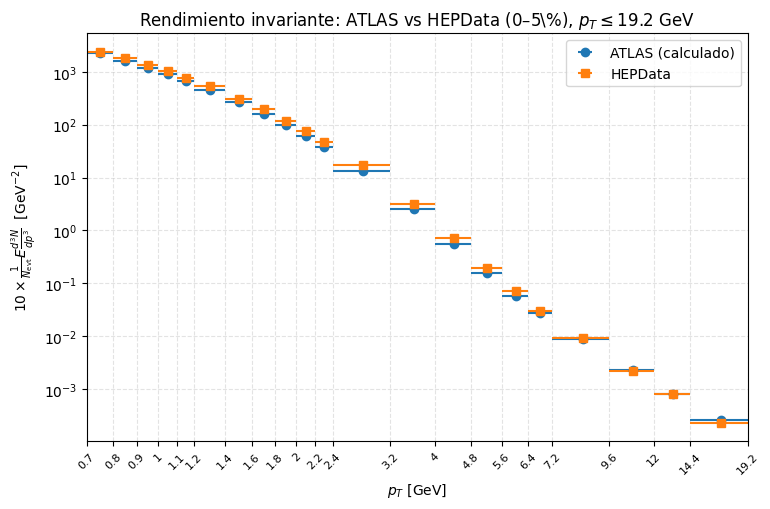

In [16]:
# =========================
# (DESPUÉS de tu tabla_invar) Comparación ATLAS (calculado) vs HEPData + GRÁFICO SUPERPUESTO (RECORTE pT<=19.2)
# =========================
import re

PT_MAX = 19.2  # <-- recorte máximo en pT (GeV)

hep_archivos_por_centralidad = {(0, 5): "HEPData-ins1496050-v2-Table_1.csv", (5, 10): "HEPData-ins1496050-v2-Table_2.csv", (10, 30): "HEPData-ins1496050-v2-Table_3.csv", (30, 50): "HEPData-ins1496050-v2-Table_4.csv", (50, 70): "HEPData-ins1496050-v2-Table_5.csv", (70, 90): "HEPData-ins1496050-v2-Table_6.csv"}
clave_cent = (CENT_LO, CENT_HI)
if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(f"No tengo mapeado el archivo HEPData para centralidad {CENT_LO}-{CENT_HI}%. Opciones válidas: {sorted(list(hep_archivos_por_centralidad.keys()))}")
archivo_hep = hep_archivos_por_centralidad[clave_cent]
df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")

pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
y_hep_raw   = df_hep.iloc[:, 3].astype(float).to_numpy()

factor_hep = 1.0
try:
    nombre_col_valor = str(df_hep.columns[3])
    m = re.match(r"^\s*([0-9]+(?:\.[0-9]+)?)\s*\*", nombre_col_valor)
    if m: factor_hep = float(m.group(1))
except Exception:
    factor_hep = 1.0

y_hep = y_hep_raw * (FACTOR_INV / factor_hep)

tabla_hep = pd.DataFrame({"pT_low [GeV]": pt_low_hep, "pT_high [GeV]": pt_high_hep, "pT_center [GeV]": pt_hep, "HEP_value": y_hep})

col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"

# ===> AQUÍ SOLO AÑADO "counts" (tus cuentas) y lo renombro
tabla_atlas = tabla_invar[["pT_low [GeV]", "pT_high [GeV]", "pT_center [GeV]", col_y, "counts"]].copy().rename(columns={col_y: "ATLAS_value", "counts": "Cuentas ATLAS (tracks)"})

for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{v:.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{v:.6f}")

tabla_comp = pd.merge(tabla_atlas, tabla_hep[["_low_key", "_high_key", "HEP_value"]], on=["_low_key", "_high_key"], how="inner")

# ===> RECORTE pT: conservar bins con borde superior <= 19.2 GeV
tabla_comp = tabla_comp[tabla_comp["pT_high [GeV]"] <= PT_MAX].copy()

tabla_comp["Porcentaje de error [%]"] = (np.abs(tabla_comp["ATLAS_value"] - tabla_comp["HEP_value"]) / tabla_comp["HEP_value"]) * 100.0

# ===> renombre igual que vos, pero conservando cuentas
tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "ATLAS_value": "Valor medido ATLAS",
    "HEP_value": "Valor medido HEP",
})

# ===> mover "Cuentas..." a la par del % error (después de %)
tabla_comp = tabla_comp[[
    "PTlow [GeV]", "PThigh [GeV]", "PT [GeV]",
    "Valor medido ATLAS", "Valor medido HEP",
    "Porcentaje de error [%]", "Cuentas ATLAS (tracks)"
]].copy()

# =========================
# FILAS FINALES: Total cuentas y Promedio % error
# =========================
total_cuentas = int(np.nansum(tabla_comp["Cuentas ATLAS (tracks)"].to_numpy(dtype=float)))
prom_error = float(np.nanmean(tabla_comp["Porcentaje de error [%]"].to_numpy(dtype=float)))

fila_total = {
    "PTlow [GeV]": np.nan, "PThigh [GeV]": np.nan, "PT [GeV]": "Total cuentas",
    "Valor medido ATLAS": np.nan, "Valor medido HEP": np.nan,
    "Porcentaje de error [%]": np.nan,
    "Cuentas ATLAS (tracks)": total_cuentas,
}
fila_prom = {
    "PTlow [GeV]": np.nan, "PThigh [GeV]": np.nan, "PT [GeV]": "Promedio % error",
    "Valor medido ATLAS": np.nan, "Valor medido HEP": np.nan,
    "Porcentaje de error [%]": prom_error,
    "Cuentas ATLAS (tracks)": np.nan,
}
tabla_comp = pd.concat([tabla_comp, pd.DataFrame([fila_total, fila_prom])], ignore_index=True)

# =========================
# DISPLAY (sin que reviente el formato de enteros)
# =========================
def fmt_int_or_blank(x):
    if pd.isna(x):
        return ""
    return f"{int(x):d}"

print(f"\nTabla: Comparación ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}% (archivo: {archivo_hep})  con recorte pT <= {PT_MAX} GeV")
display(tabla_comp.style.format({
    "PTlow [GeV]": "{:.1f}",
    "PThigh [GeV]": "{:.1f}",
    "PT [GeV]": "{}",
    "Valor medido ATLAS": "{:.15f}",
    "Valor medido HEP": "{:.15f}",
    "Porcentaje de error [%]": "{:.6f}",
    "Cuentas ATLAS (tracks)": fmt_int_or_blank,   # <-- clave para evitar tu error
}))

# =========================
# GRÁFICO SUPERPUESTO (igual que vos)
# =========================
x      = tabla_comp.loc[pd.to_numeric(tabla_comp["PT [GeV]"], errors="coerce").notna(), "PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_comp.loc[pd.to_numeric(tabla_comp["PT [GeV]"], errors="coerce").notna(), "Valor medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_comp.loc[pd.to_numeric(tabla_comp["PT [GeV]"], errors="coerce").notna(), "Valor medido HEP"].to_numpy(dtype=float)
ptlow  = tabla_comp.loc[pd.to_numeric(tabla_comp["PT [GeV]"], errors="coerce").notna(), "PTlow [GeV]"].to_numpy(dtype=float)
pthigh = tabla_comp.loc[pd.to_numeric(tabla_comp["PT [GeV]"], errors="coerce").notna(), "PThigh [GeV]"].to_numpy(dtype=float)
xerr   = np.vstack([x - ptlow, pthigh - x])

m = np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) & (x > 0) & (y_at > 0) & (y_hep2 > 0)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(x[m], y_at[m], xerr=xerr[:, m], fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)")
ax.errorbar(x[m], y_hep2[m], xerr=xerr[:, m], fmt="s", linestyle="none", capsize=0, label="HEPData")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(float(np.min(ptlow)) if len(ptlow) else 0.7, PT_MAX)
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]")
ax.set_title(rf"Rendimiento invariante: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%), $p_T\leq{PT_MAX}$ GeV")
ax.grid(True, which="both", ls="--", alpha=0.35); ax.legend()

if "pt_intervalos" in globals():
    ticks = pt_intervalos[pt_intervalos <= PT_MAX]
else:
    ticks = np.unique(np.concatenate([ptlow, pthigh])); ticks = ticks[ticks <= PT_MAX]
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

### Observación: Obtuve una muy buena aproximación de los valores numéricos en valores de momentos transversos "bajos".

# Espectro diferencial de la sección eficaz inelástica en colisiones protón-protón

### Tomé los datos de HEP (Tabla 7)


Tabla: Espectro pp (HEPData Table 7)


,pT_low [GeV],pT_high [GeV],pT_center [GeV],(1/N) E d^3N/dp^3 [GeV^-2]
0,0.5,0.6,0.55,9.756980e-01
1,0.6,0.7,0.65,6.396480e-01
2,0.7,0.8,0.75,4.193870e-01
3,0.8,0.9,0.85,2.969680e-01
4,0.9,1.0,0.95,2.039110e-01
5,1.0,1.1,1.05,1.472850e-01
6,1.1,1.2,1.15,1.067570e-01
7,1.2,1.4,1.30,6.983660e-02
8,1.4,1.6,1.50,3.930150e-02
9,1.6,1.8,1.70,2.388490e-02


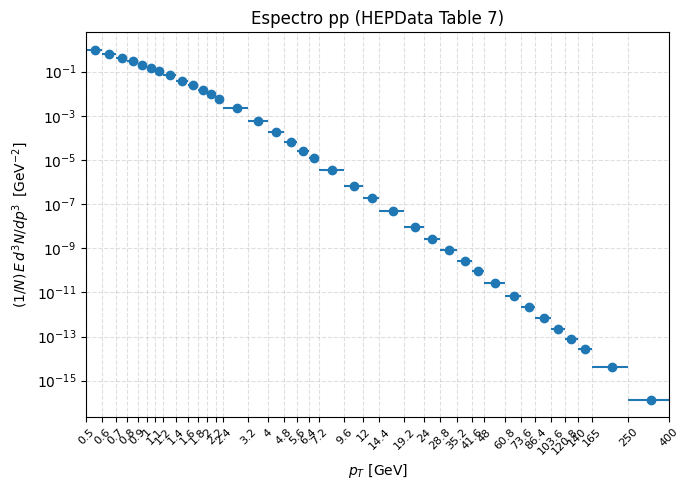

In [17]:
# =========================
# 1) Leer CSV ignorando el header con "#"
# =========================
archivo = "HEPData-Table_7-Espectro-pp.csv"

df = pd.read_csv(
    archivo,
    comment="#",
    sep=",",
    engine="python"
)

# =========================
# 2) Tomar columnas (LOW/HIGH) para pT y el espectro
# =========================
pt_low  = df.iloc[:, 1].astype(float).to_numpy()   # PT [GeV] LOW
pt_high = df.iloc[:, 2].astype(float).to_numpy()   # PT [GeV] HIGH

pt   = 0.5 * (pt_low + pt_high)                    # centro del bin
xerr = np.vstack([pt - pt_low, pt_high - pt])      # barras horizontales

y = df.iloc[:, 3].astype(float).to_numpy()         # (1/N) E d^3N/dp^3 [GeV^-2]

# =========================
# 2.5) Tabla (similar a la anterior)
# =========================
tabla_pp = pd.DataFrame({
    "pT_low [GeV]": pt_low,
    "pT_high [GeV]": pt_high,
    "pT_center [GeV]": pt,
    "(1/N) E d^3N/dp^3 [GeV^-2]": y,
})
print("\nTabla: Espectro pp (HEPData Table 7)")
display(tabla_pp)

# =========================
# 3) Gráfico
# =========================
plt.figure(figsize=(7,5))
plt.errorbar(pt, y, xerr=xerr, fmt="o", linestyle="none", capsize=0)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel(r"$(1/N)\,E\,d^3N/dp^3\ \,[\mathrm{GeV}^{-2}]$")
plt.title("Espectro pp (HEPData Table 7)")
plt.grid(True, which="both", ls="--", alpha=0.4)

# =========================
# Ticks del eje x = bordes reales de bins
# =========================
ticks = np.unique(np.concatenate([pt_low, pt_high]))
ticks = np.sort(ticks)

ax = plt.gca()
ax.set_xlim(ticks.min(), ticks.max())
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# Factor de modificación nuclear/Función de soplamiento nuclear promedio (TAA)

### La información la puedo encontrar en: 

- Punto uno ATLAS-CONF-2017-012: Mean values of
https://cds.cern.ch/record/2244824/files/ATLAS-CONF-2017-012.pdf  
CERN Document Server

- Punto dos CMS Charged-particle nuclear modification factors at 5.02 TeV — contiene RAA y la incertidumbre de TAA que se usa en el análisis:
 📄 https://arxiv.org/pdf/1611.01664.pdf

- Punto tres ATLAS y ALICE measurements de espectros y RAA en Pb-Pb 5.02 TeV — muestran resultados de RAA,implica el uso de TAA del Glauber model:
 📄 https://cds.cern.ch/record/2842355/files/ANA-HION-2018-17-PAPER.pdf

- Punto cuatro https://doi.org/10.1016/j.physletb.2018.10.076
 

# FACTOR DE MODIFICACIÓN NUCLEAR (RAA)

TAA asignado automáticamente para 30-50%: 3.82 mb^-1


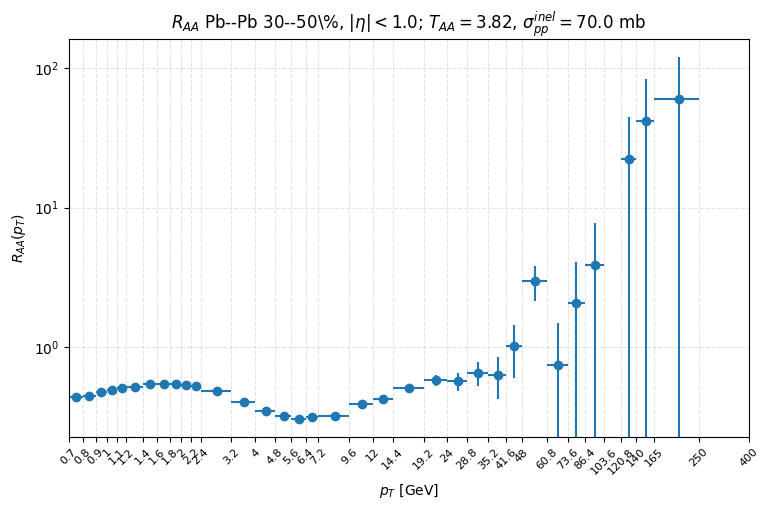

Nevt total (PbPb 30–50%) = 68,234
Bins válidos (counts>0 y pp dentro de rango) = 33 / 35

Tabla: RAA (solo bins válidos)


,PT_low [GeV],PThigh [GeV],PT_center [GeV],RAA
0,0.7,0.8,0.75,0.435788615690590
1,0.8,0.9,0.85,0.444321333730935
2,0.9,1.0,0.95,0.475780803966318
3,1.0,1.1,1.05,0.491427099079920
4,1.1,1.2,1.15,0.509472098015160
5,1.2,1.4,1.30,0.519994889867582
6,1.4,1.6,1.50,0.542972355517636
7,1.6,1.8,1.70,0.538618736346657
8,1.8,2.0,1.90,0.546385634245667
9,2.0,2.2,2.10,0.530469102190348


In [24]:
# =========================================================
# A) CONFIGURACIÓN  (solo cambias CENTRALIDAD; TAA se asigna solo)
# =========================================================
CENT_LO, CENT_HI = 30.0, 50.0     # centralidad PbPb (elige una de las mapeadas abajo)
SIGMA_PP_INEL = 70.0            # [mb]

FACTOR_INV_PBPB = 1.0           # factor multiplicativo PbPb
FACTOR_INV_PP   = 1.0           # factor multiplicativo pp

ETA_MAX = 1.0
CSV_PP = "HEPData-Table_7-Espectro-pp.csv"

pt_intervalos = np.array([
    0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 3.2, 4.0,
    4.8, 5.6, 6.4, 7.2, 9.6, 12.0, 14.4, 19.2, 24.0, 28.8, 35.2, 41.6,
    48.0, 60.8, 73.6, 86.4, 103.6, 120.8, 140.0, 165.0, 250.0, 400.0
], dtype=float)

# =========================================================
# A.1) TAA AUTOMÁTICO SEGÚN CENTRALIDAD (NO cambies nombres)
# =========================================================
TAA_por_centralidad = {
    (0.0, 5.0):  26.23,
    (5.0, 10.0): 20.47,
    (10.0, 30.0): 11.7,
    (30.0, 50.0): 3.82,
    (50.0, 70.0): 0.934,
    (70.0, 100.0): 0.152,
}

clave_cent = (float(CENT_LO), float(CENT_HI))
if clave_cent not in TAA_por_centralidad:
    raise ValueError(
        f"No tengo TAA mapeado para {CENT_LO}-{CENT_HI}%. "
        f"Opciones válidas: {sorted(TAA_por_centralidad.keys())}"
    )

TAA = TAA_por_centralidad[clave_cent]
print(f"TAA asignado automáticamente para {CENT_LO:.0f}-{CENT_HI:.0f}%: {TAA} mb^-1")

# =========================================================
# B) FUNCIÓN: PbPb (MULTI-ARCHIVO con chunks) -> inv. yield por bin
# =========================================================
def pbpb_invariant_yield_twofiles(
    archivos_ct,
    CENT_LO, CENT_HI,
    FACTOR_INV_PBPB,
    ETA_MAX,
    pt_intervalos,
    step_size="200 MB",
    timeout=600
):
    ramas = [
        "InDetTrackParticlesAuxDyn.qOverP",
        "InDetTrackParticlesAuxDyn.theta",
        "EventInfoAuxDyn.CentralityMin",
        "EventInfoAuxDyn.CentralityMax",
    ]

    Nevt_total = 0
    counts_total = np.zeros(len(pt_intervalos) - 1, dtype=np.int64)

    for arrays in uproot.iterate(
        archivos_ct,
        ramas,
        step_size=step_size,
        library="ak",
        timeout=timeout,
    ):
        cent_min = arrays["EventInfoAuxDyn.CentralityMin"]
        cent_max = arrays["EventInfoAuxDyn.CentralityMax"]
        centrality_prom_event = 0.5 * (cent_min + cent_max)

        mask_evt = (centrality_prom_event >= CENT_LO) & (centrality_prom_event < CENT_HI)

        Nevt_chunk = int(ak.sum(mask_evt))
        if Nevt_chunk == 0:
            continue
        Nevt_total += Nevt_chunk

        qOverP_sel = arrays["InDetTrackParticlesAuxDyn.qOverP"][mask_evt]
        theta_sel  = arrays["InDetTrackParticlesAuxDyn.theta"][mask_evt]

        valid = (qOverP_sel != 0) & np.isfinite(qOverP_sel) & np.isfinite(theta_sel)
        qOverP_sel = qOverP_sel[valid]
        theta_sel  = theta_sel[valid]

        p_mev  = 1.0 / np.abs(qOverP_sel)
        pt_mev = p_mev * np.sin(theta_sel)
        pt_gev = pt_mev / 1000.0

        eta_sel = -np.log(np.tan(theta_sel / 2.0))
        mask_eta = np.abs(eta_sel) < ETA_MAX

        pt_filtrado = ak.to_numpy(ak.flatten(pt_gev[mask_eta]))

        counts_chunk, _ = np.histogram(pt_filtrado, bins=pt_intervalos)
        counts_total += counts_chunk.astype(np.int64)

    if Nevt_total == 0:
        raise ValueError("Nevt_total=0 en ese rango de centralidad. Cambia CENT_LO/CENT_HI o revisa datos.")

    pt_low  = pt_intervalos[:-1]
    pt_high = pt_intervalos[1:]
    dpt     = np.diff(pt_intervalos)
    pt_c    = 0.5 * (pt_low + pt_high)

    Delta_eta = 2.0 * ETA_MAX
    spec      = counts_total / (Nevt_total * Delta_eta * dpt)
    spec_err  = np.sqrt(counts_total) / (Nevt_total * Delta_eta * dpt)

    inv      = FACTOR_INV_PBPB * spec / (2.0 * np.pi * pt_c)
    inv_err  = FACTOR_INV_PBPB * spec_err / (2.0 * np.pi * pt_c)

    return {
        "Nevt": Nevt_total,
        "pt_low": pt_low, "pt_high": pt_high, "pt_c": pt_c,
        "counts": counts_total,
        "inv": inv, "inv_err": inv_err
    }

# =========================================================
# C) FUNCIÓN: leer pp (HEPData) y devolver y(pp)(pT) + err(pp)(pT)
# =========================================================
def pp_invariant_yield_from_csv(CSV_PP, FACTOR_INV_PP, pt_eval):
    df = pd.read_csv(CSV_PP, comment="#", sep=",", engine="python")

    pt_low  = df.iloc[:, 1].astype(float).to_numpy()
    pt_high = df.iloc[:, 2].astype(float).to_numpy()
    pt      = 0.5 * (pt_low + pt_high)
    y       = df.iloc[:, 3].astype(float).to_numpy()

    yerr = None
    if df.shape[1] >= 5:
        try:
            yerr = df.iloc[:, 4].astype(float).to_numpy()
        except Exception:
            yerr = None

    y = FACTOR_INV_PP * y
    if yerr is not None:
        yerr = FACTOR_INV_PP * yerr

    mask_ok = (pt > 0) & np.isfinite(pt) & (y > 0) & np.isfinite(y)
    pt_ok = pt[mask_ok]
    y_ok  = y[mask_ok]

    logpt = np.log(pt_ok)
    logy  = np.log(y_ok)

    pt_min, pt_max = pt_ok.min(), pt_ok.max()
    mask_range = (pt_eval >= pt_min) & (pt_eval <= pt_max) & np.isfinite(pt_eval) & (pt_eval > 0)

    y_interp = np.full_like(pt_eval, np.nan, dtype=float)
    y_interp[mask_range] = np.exp(np.interp(np.log(pt_eval[mask_range]), logpt, logy))

    if yerr is not None:
        yerr_ok = yerr[mask_ok]
        rel = np.where(y_ok > 0, yerr_ok / y_ok, np.nan)
        rel_interp = np.full_like(pt_eval, np.nan, dtype=float)
        rel_interp[mask_range] = np.interp(np.log(pt_eval[mask_range]), logpt, rel)
        yerr_interp = rel_interp * y_interp
    else:
        yerr_interp = np.zeros_like(pt_eval, dtype=float)

    return {"y_interp": y_interp, "yerr_interp": yerr_interp}

# =========================================================
# D) CALCULAR PbPb (2+ archivos) + pp + R_AA
# =========================================================
pb = pbpb_invariant_yield_twofiles(
    archivos_ct,
    CENT_LO, CENT_HI,
    FACTOR_INV_PBPB,
    ETA_MAX,
    pt_intervalos,
    step_size="200 MB",
    timeout=600
)

pt_low  = pb["pt_low"]
pt_high = pb["pt_high"]
pt_c    = pb["pt_c"]
xerr    = np.vstack([pt_c - pt_low, pt_high - pt_c])

inv_pb   = pb["inv"]
inv_pb_e = pb["inv_err"]
counts   = pb["counts"]

pp = pp_invariant_yield_from_csv(CSV_PP, FACTOR_INV_PP, pt_c)
inv_pp_interp   = pp["y_interp"]
inv_pp_interp_e = pp["yerr_interp"]

denom      = (TAA * SIGMA_PP_INEL) * inv_pp_interp
denom_err  = (TAA * SIGMA_PP_INEL) * inv_pp_interp_e

RAA = inv_pb / denom
RAA_err = np.abs(RAA) * np.sqrt(
    (inv_pb_e / np.where(inv_pb != 0, inv_pb, np.nan))**2 +
    (denom_err / np.where(denom != 0, denom, np.nan))**2
)

mask = (
    (counts > 0) &
    np.isfinite(RAA) & np.isfinite(RAA_err) &
    np.isfinite(denom) & (denom > 0) &
    np.isfinite(inv_pb) & (inv_pb > 0)
)

# =========================================================
# E) GRAFICAR RAA
# =========================================================
plt.figure(figsize=(7.8, 5.2))
plt.errorbar(
    pt_c[mask], RAA[mask],
    xerr=xerr[:, mask], yerr=RAA_err[mask],
    fmt="o", linestyle="none", capsize=0
)
plt.xscale("log")
plt.yscale("log")
plt.xlim(pt_intervalos[0], pt_intervalos[-1])
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel(r"$R_{AA}(p_T)$")
plt.title(rf"$R_{{AA}}$ Pb--Pb {CENT_LO:.0f}--{CENT_HI:.0f}\%, $|\eta|<{ETA_MAX}$; $T_{{AA}}={TAA}$, $\sigma_{{pp}}^{{inel}}={SIGMA_PP_INEL}$ mb")
plt.grid(True, which="both", ls="--", alpha=0.35)

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator(pt_intervalos))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in pt_intervalos]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

print(f"Nevt total (PbPb {CENT_LO:.0f}–{CENT_HI:.0f}%) = {pb['Nevt']:,}")
print(f"Bins válidos (counts>0 y pp dentro de rango) = {int(np.sum(mask))} / {len(pt_c)}")

# =========================================================
# F) TABLA RAA (misma idea que tu tabla)
# =========================================================
tabla_raa = pd.DataFrame({
    "PT_low [GeV]":     pt_low[mask],
    "PThigh [GeV]":     pt_high[mask],
    "PT_center [GeV]":  pt_c[mask],
    "RAA":              RAA[mask],
})

print("\nTabla: RAA (solo bins válidos)")
display(tabla_raa.style.format({
    "PT_low [GeV]": "{:.1f}",
    "PThigh [GeV]": "{:.1f}",
    "PT_center [GeV]": "{:.2f}",
    "RAA": "{:.15f}",
}))

# Comparando resultados


Tabla: Comparación R_AA ATLAS vs HEPData para centralidad 30.0-50.0%  (archivo: HEPData-ins1496050-v2-Table_11.csv)


,PTlow [GeV],PThigh [GeV],PT [GeV],RAA medido ATLAS,RAA medido HEP,Cuentas (ATLAS),Porcentaje de error [%]
0,0.7,0.8,0.75,0.435789,0.424114,3142854,2.753
1,0.8,0.9,0.85,0.444321,0.450430,2571567,1.356
2,0.9,1.0,0.95,0.475781,0.484956,2113213,1.892
3,1.0,1.1,1.05,0.491427,0.509379,1742525,3.524
4,1.1,1.2,1.15,0.509472,0.524695,1434124,2.901
5,1.2,1.4,1.30,0.519995,0.550884,2164849,5.607
6,1.4,1.6,1.50,0.542972,0.569072,1467845,4.586
7,1.6,1.8,1.70,0.538619,0.585949,1002896,8.078
8,1.8,2.0,1.90,0.546386,0.587203,688553,6.951
9,2.0,2.2,2.10,0.530469,0.583266,473877,9.052


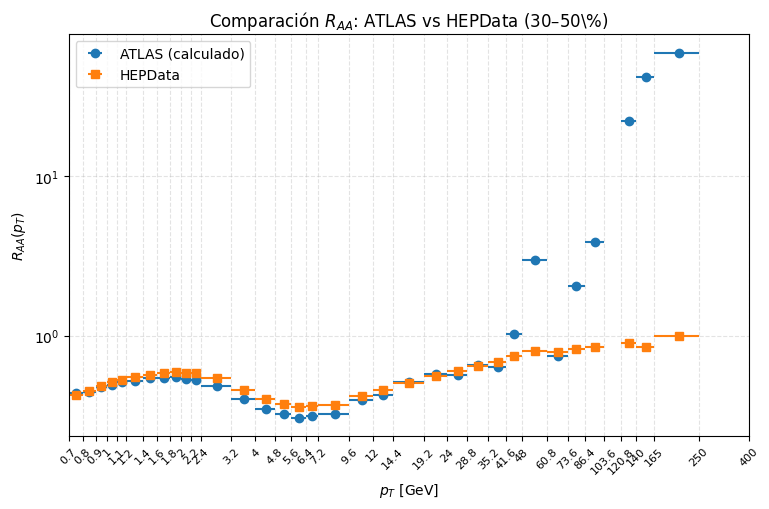

In [25]:
# =========================================================
# COMPARACIÓN R_AA: ATLAS (calculado) vs HEPData  +  GRÁFICO SUPERPUESTO
# (asume que YA existen: pt_low, pt_high, pt_c, RAA, mask, y CENT_LO/CENT_HI)
# + mantiene columna de CUENTAS y agrega SOLO fila: TOTAL CUENTAS
# =========================================================
import re

# --- Mapeo correcto de archivos HEPData para R_AA ---
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_8.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_9.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_10.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_11.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_12.csv",
    (70, 100): "HEPData-ins1496050-v2-Table_13.csv",
}

clave_cent = (CENT_LO, CENT_HI)
if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No hay archivo HEPData para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {list(hep_archivos_por_centralidad.keys())}"
    )

archivo_hep = hep_archivos_por_centralidad[clave_cent]

# =========================================================
# 1) LEER R_AA DE HEPData
# =========================================================
df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")

pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
raa_hep     = df_hep.iloc[:, 3].astype(float).to_numpy()

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_RAA": raa_hep,
})

# =========================================================
# 2) TABLA ATLAS (DESDE TU CÁLCULO) + CUENTAS
# =========================================================
# Intentar tomar cuentas desde tu notebook (sin romper si no existen)
if "counts" in globals():
    counts_use = counts
elif "counts_RAA" in globals():
    counts_use = counts_RAA
else:
    counts_use = None

if counts_use is None:
    counts_atlas = np.full(np.sum(mask), np.nan, dtype=float)
else:
    counts_atlas = np.asarray(counts_use)[mask]

tabla_atlas = pd.DataFrame({
    "pT_low [GeV]": pt_low[mask],
    "pT_high [GeV]": pt_high[mask],
    "pT_center [GeV]": pt_c[mask],
    "ATLAS_RAA": RAA[mask],
    "counts": counts_atlas,   # <-- CUENTAS ATLAS (por bin)
})

# =========================================================
# 3) MERGE ROBUSTO POR BORDES DE BIN
# =========================================================
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{v:.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{v:.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_RAA"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

# =========================================================
# 4) PORCENTAJE DE ERROR
# =========================================================
tabla_comp["Porcentaje de error [%]"] = (
    np.abs(tabla_comp["ATLAS_RAA"] - tabla_comp["HEP_RAA"])
    / tabla_comp["HEP_RAA"]
) * 100.0

# =========================================================
# 5) LIMPIEZA FINAL DE COLUMNAS (manteniendo CUENTAS)
# =========================================================
tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "ATLAS_RAA": "RAA medido ATLAS",
    "HEP_RAA": "RAA medido HEP",
    "counts": "Cuentas (ATLAS)",
})

# Reordenar columnas (CUENTAS al lado del % error)
orden_cols = [
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "RAA medido ATLAS",
    "RAA medido HEP",
    "Cuentas (ATLAS)",
    "Porcentaje de error [%]",
]
tabla_comp = tabla_comp[orden_cols]

# =========================================================
# 6) FILA FINAL: TOTAL CUENTAS (SIN FILA DE PROMEDIO ERROR)
# =========================================================
total_cuentas = np.nan
if np.any(np.isfinite(tabla_comp["Cuentas (ATLAS)"].to_numpy(dtype=float))):
    total_cuentas = int(np.nansum(tabla_comp["Cuentas (ATLAS)"].to_numpy(dtype=float)))

fila_total = {
    "PTlow [GeV]": np.nan,
    "PThigh [GeV]": np.nan,
    "PT [GeV]": "Total cuentas",
    "RAA medido ATLAS": np.nan,
    "RAA medido HEP": np.nan,
    "Cuentas (ATLAS)": total_cuentas,
    "Porcentaje de error [%]": np.nan,
}

tabla_comp = pd.concat([tabla_comp, pd.DataFrame([fila_total])], ignore_index=True)

# =========================================================
# 7) MOSTRAR TABLA FINAL
# =========================================================
print(
    f"\nTabla: Comparación R_AA ATLAS vs HEPData "
    f"para centralidad {CENT_LO}-{CENT_HI}%  (archivo: {archivo_hep})"
)

def fmt_num(dec):
    def _f(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return ""
        if isinstance(x, str):
            return x
        return f"{float(x):.{dec}f}"
    return _f

def fmt_int(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    if isinstance(x, str):
        return x
    return f"{int(x):d}"

display(
    tabla_comp.style.format({
        "PTlow [GeV]": fmt_num(1),
        "PThigh [GeV]": fmt_num(1),
        "PT [GeV]": fmt_num(2),            # <-- DOS DECIMALES
        "RAA medido ATLAS": fmt_num(6),
        "RAA medido HEP": fmt_num(6),
        "Cuentas (ATLAS)": fmt_int,
        "Porcentaje de error [%]": fmt_num(3),
    })
)

# =========================================================
# 8) GRÁFICO SUPERPUESTO: ATLAS vs HEPData (mismos bins)
# =========================================================
# Quitamos la última fila (Total cuentas) para el plot
tabla_plot = tabla_comp.iloc[:-1].copy()

x      = tabla_plot["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_plot["RAA medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_plot["RAA medido HEP"].to_numpy(dtype=float)

ptlow  = tabla_plot["PTlow [GeV]"].to_numpy(dtype=float)
pthigh = tabla_plot["PThigh [GeV]"].to_numpy(dtype=float)
xerr   = np.vstack([x - ptlow, pthigh - x])

m = np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) & (x > 0) & (y_at > 0) & (y_hep2 > 0)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(x[m], y_at[m], xerr=xerr[:, m], fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)")
ax.errorbar(x[m], y_hep2[m], xerr=xerr[:, m], fmt="s", linestyle="none", capsize=0, label="HEPData")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(rf"Comparación $R_{{AA}}$: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%)")
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

# ticks = tus bordes de bins (si existe pt_intervalos en tu notebook úsalo; si no, usa los bordes de la tabla)
if "pt_intervalos" in globals():
    ticks = pt_intervalos
else:
    ticks = np.unique(np.concatenate([ptlow, pthigh]))
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

ax.set_xlim(float(np.min(ticks)), float(np.max(ticks)))
plt.tight_layout()
plt.show()

Me funciona bien para intervalos menores a 30%

# Acortando el intervalo de PT


Tabla: Comparación R_AA ATLAS vs HEPData para centralidad 30.0-50.0% (archivo: HEPData-ins1496050-v2-Table_11.csv)  |  corte: pT <= 19.2 GeV


,PTlow [GeV],PThigh [GeV],PT [GeV],RAA medido ATLAS,RAA medido HEP,Cuentas (ATLAS),Porcentaje de error [%]
0,0.7,0.8,0.75,0.435789,0.424114,3142854,2.753
1,0.8,0.9,0.85,0.444321,0.450430,2571567,1.356
2,0.9,1.0,0.95,0.475781,0.484956,2113213,1.892
3,1.0,1.1,1.05,0.491427,0.509379,1742525,3.524
4,1.1,1.2,1.15,0.509472,0.524695,1434124,2.901
5,1.2,1.4,1.30,0.519995,0.550884,2164849,5.607
6,1.4,1.6,1.50,0.542972,0.569072,1467845,4.586
7,1.6,1.8,1.70,0.538619,0.585949,1002896,8.078
8,1.8,2.0,1.90,0.546386,0.587203,688553,6.951
9,2.0,2.2,2.10,0.530469,0.583266,473877,9.052


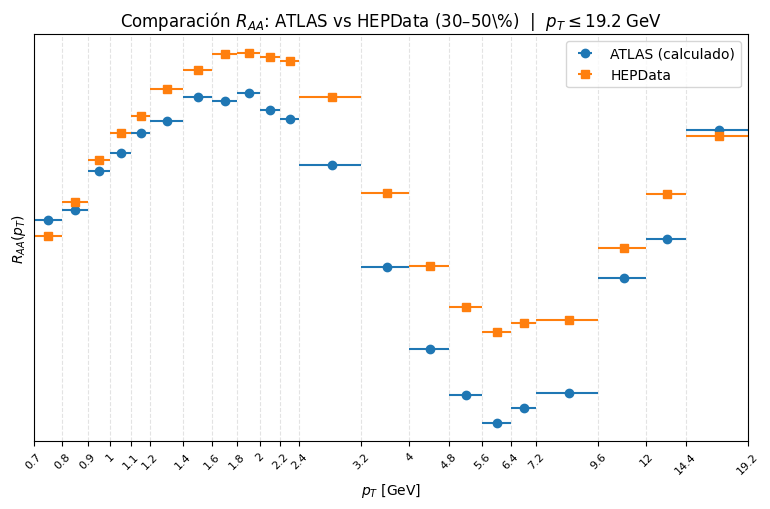

In [26]:
# =========================================================
# COMPARACIÓN R_AA: ATLAS (calculado) vs HEPData  +  GRÁFICO SUPERPUESTO
# (asume que YA existen: pt_low, pt_high, pt_c, RAA, mask, y CENT_LO/CENT_HI)
# =========================================================

PT_MAX = 19.2  # <-- corte máximo en pT (GeV) para tabla + gráfico

# --- Mapeo correcto de archivos HEPData para R_AA ---
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_8.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_9.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_10.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_11.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_12.csv",
    (70, 100): "HEPData-ins1496050-v2-Table_13.csv",
}

clave_cent = (CENT_LO, CENT_HI)
if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No hay archivo HEPData para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {list(hep_archivos_por_centralidad.keys())}"
    )

archivo_hep = hep_archivos_por_centralidad[clave_cent]

# =========================================================
# 1) LEER R_AA DE HEPData + RECORTE (pT_high <= PT_MAX)
# =========================================================
df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")

pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
raa_hep     = df_hep.iloc[:, 3].astype(float).to_numpy()

mask_hep_pt = np.isfinite(pt_low_hep) & np.isfinite(pt_high_hep) & np.isfinite(raa_hep) & (pt_high_hep <= PT_MAX)
pt_low_hep, pt_high_hep, pt_hep, raa_hep = pt_low_hep[mask_hep_pt], pt_high_hep[mask_hep_pt], pt_hep[mask_hep_pt], raa_hep[mask_hep_pt]

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_RAA": raa_hep,
})

# =========================================================
# 2) TABLA ATLAS (DESDE TU CÁLCULO) + CUENTAS + RECORTE (pt_high <= PT_MAX)
# =========================================================
# Intentar tomar cuentas desde tu notebook (sin romper si no existen)
if "counts" in globals():
    counts_use = counts
elif "counts_RAA" in globals():
    counts_use = counts_RAA
else:
    counts_use = None

mask_atlas_pt = (pt_high <= PT_MAX)
mask_use = mask & mask_atlas_pt

if counts_use is None:
    counts_atlas = np.full(np.sum(mask_use), np.nan, dtype=float)
else:
    counts_atlas = np.asarray(counts_use)[mask_use]

tabla_atlas = pd.DataFrame({
    "pT_low [GeV]": pt_low[mask_use],
    "pT_high [GeV]": pt_high[mask_use],
    "pT_center [GeV]": pt_c[mask_use],
    "ATLAS_RAA": RAA[mask_use],
    "counts": counts_atlas,   # <-- CUENTAS ATLAS (por bin)
})

# =========================================================
# 3) MERGE ROBUSTO POR BORDES DE BIN
# =========================================================
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{v:.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{v:.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_RAA"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

# (doble seguridad) dejar solo bins con borde superior <= PT_MAX
tabla_comp = tabla_comp[tabla_comp["pT_high [GeV]"] <= PT_MAX].copy()

# =========================================================
# 4) PORCENTAJE DE ERROR
# =========================================================
tabla_comp["Porcentaje de error [%]"] = (
    np.abs(tabla_comp["ATLAS_RAA"] - tabla_comp["HEP_RAA"]) / tabla_comp["HEP_RAA"]
) * 100.0

# =========================================================
# 5) LIMPIEZA FINAL DE COLUMNAS (manteniendo CUENTAS)
# =========================================================
tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "ATLAS_RAA": "RAA medido ATLAS",
    "HEP_RAA": "RAA medido HEP",
    "counts": "Cuentas (ATLAS)",
})

# Reordenar columnas (CUENTAS al lado del % error)
orden_cols = [
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "RAA medido ATLAS",
    "RAA medido HEP",
    "Cuentas (ATLAS)",
    "Porcentaje de error [%]",
]
tabla_comp = tabla_comp[orden_cols]

# =========================================================
# 6) FILAS FINALES: PROMEDIO ERROR + TOTAL CUENTAS
# =========================================================
# promedio del % error (ignorando NaN)
err_vals = pd.to_numeric(tabla_comp["Porcentaje de error [%]"], errors="coerce").to_numpy(dtype=float)
prom_error = float(np.nanmean(err_vals)) if np.any(np.isfinite(err_vals)) else np.nan

# total de cuentas (ignorando NaN)
cnt_vals = pd.to_numeric(tabla_comp["Cuentas (ATLAS)"], errors="coerce").to_numpy(dtype=float)
total_cuentas = int(np.nansum(cnt_vals)) if np.any(np.isfinite(cnt_vals)) else np.nan

fila_prom = {
    "PTlow [GeV]": np.nan,
    "PThigh [GeV]": np.nan,
    "PT [GeV]": "Promedio error",
    "RAA medido ATLAS": np.nan,
    "RAA medido HEP": np.nan,
    "Cuentas (ATLAS)": np.nan,
    "Porcentaje de error [%]": prom_error,
}

fila_total = {
    "PTlow [GeV]": np.nan,
    "PThigh [GeV]": np.nan,
    "PT [GeV]": "Total cuentas",
    "RAA medido ATLAS": np.nan,
    "RAA medido HEP": np.nan,
    "Cuentas (ATLAS)": total_cuentas,
    "Porcentaje de error [%]": np.nan,
}

tabla_comp = pd.concat([tabla_comp, pd.DataFrame([fila_prom, fila_total])], ignore_index=True)

# =========================================================
# 7) MOSTRAR TABLA FINAL (PT con 2 decimales)
# =========================================================
print(
    f"\nTabla: Comparación R_AA ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}% "
    f"(archivo: {archivo_hep})  |  corte: pT <= {PT_MAX} GeV"
)

def fmt_num(dec):
    def _f(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return ""
        if isinstance(x, str):
            return x
        return f"{float(x):.{dec}f}"
    return _f

def fmt_int(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    if isinstance(x, str):
        return x
    # si viene como float pero entero, lo casteamos bien
    return f"{int(round(float(x))):d}"

display(
    tabla_comp.style.format({
        "PTlow [GeV]": fmt_num(1),
        "PThigh [GeV]": fmt_num(1),
        "PT [GeV]": fmt_num(2),             # <-- DOS DECIMALES
        "RAA medido ATLAS": fmt_num(6),
        "RAA medido HEP": fmt_num(6),
        "Cuentas (ATLAS)": fmt_int,         # <-- evita el error 'd' con floats
        "Porcentaje de error [%]": fmt_num(3),
    })
)

# =========================================================
# 8) GRÁFICO SUPERPUESTO: ATLAS vs HEPData (mismos bins, pT<=PT_MAX)
# =========================================================
# Quitamos las 2 últimas filas (Promedio error, Total cuentas) para el plot
tabla_plot = tabla_comp.iloc[:-2].copy()

x      = pd.to_numeric(tabla_plot["PT [GeV]"], errors="coerce").to_numpy(dtype=float)
y_at   = pd.to_numeric(tabla_plot["RAA medido ATLAS"], errors="coerce").to_numpy(dtype=float)
y_hep2 = pd.to_numeric(tabla_plot["RAA medido HEP"], errors="coerce").to_numpy(dtype=float)

ptlow  = pd.to_numeric(tabla_plot["PTlow [GeV]"], errors="coerce").to_numpy(dtype=float)
pthigh = pd.to_numeric(tabla_plot["PThigh [GeV]"], errors="coerce").to_numpy(dtype=float)
xerr   = np.vstack([x - ptlow, pthigh - x])

m = np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) & (x > 0) & (y_at > 0) & (y_hep2 > 0)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(x[m], y_at[m], xerr=xerr[:, m], fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)")
ax.errorbar(x[m], y_hep2[m], xerr=xerr[:, m], fmt="s", linestyle="none", capsize=0, label="HEPData")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(float(np.nanmin(ptlow)) if np.any(np.isfinite(ptlow)) else 0.7, PT_MAX)

ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(rf"Comparación $R_{{AA}}$: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%)  |  $p_T \leq {PT_MAX}$ GeV")
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

# ticks del eje x hasta PT_MAX
if "pt_intervalos" in globals():
    ticks = np.asarray(pt_intervalos)
    ticks = ticks[ticks <= PT_MAX]
else:
    ticks = np.unique(np.concatenate([ptlow[np.isfinite(ptlow)], pthigh[np.isfinite(pthigh)]]))
    ticks = ticks[ticks <= PT_MAX]

ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()